# Multi-layer Preceptron

In [ ]:
pip install matplotlib
import pandas 

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd 
import seaborn as sns

# Load the dataset
tips = sns.load_dataset('tips')
# pre processing
# convert the catagorical columns to numeric columns
tips = pd.get_dummies(tips)

# select the features and the target(predicting 'tip' based on other features)
X = tips.drop('tip', axis=1)
y = tips['tip']

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# build the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

# compile the model
model.compile(optimizer='adam', loss='mse')

# train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1, validation_data=(X_test, y_test))

# evaluate the model
loss = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}")


Epoch 1/100
7/7 [==============================] - 1s 68ms/step - loss: 10.3575 - val_loss: 6.2511
Epoch 2/100
7/7 [==============================] - 0s 26ms/step - loss: 8.3917 - val_loss: 4.7465
Epoch 3/100
7/7 [==============================] - 0s 39ms/step - loss: 6.6941 - val_loss: 3.4791
Epoch 4/100
7/7 [==============================] - 0s 32ms/step - loss: 5.1720 - val_loss: 2.4765
Epoch 5/100
7/7 [==============================] - 0s 18ms/step - loss: 3.9150 - val_loss: 1.7370
Epoch 6/100
7/7 [==============================] - 0s 27ms/step - loss: 2.9480 - val_loss: 1.2513
Epoch 7/100
7/7 [==============================] - 0s 20ms/step - loss: 2.1739 - val_loss: 1.0206
Epoch 8/100
7/7 [==============================] - 0s 17ms/step - loss: 1.7042 - val_loss: 1.0289
Epoch 9/100
7/7 [==============================] - 0s 18ms/step - loss: 1.4854 - val_loss: 1.1063
Epoch 10/100
7/7 [==============================] - 0s 22ms/step - loss: 1.3713 - val_loss: 1.1170
Epoch 11/100
7/7 [

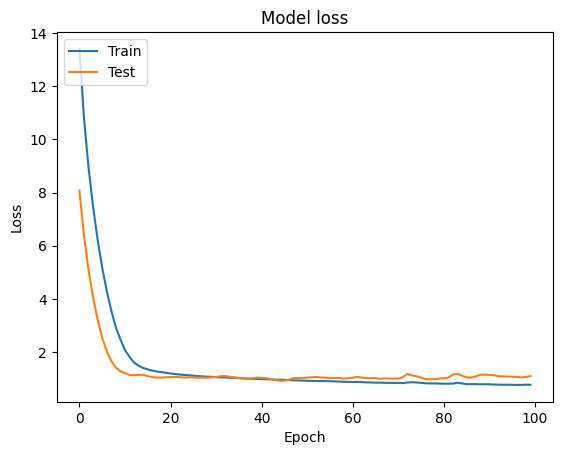

In [3]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()


-------------------

### Early Stopping of Epochs

In [7]:
from tensorflow.keras.callbacks import EarlyStopping

# build the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

# compile the model
model.compile(optimizer='adam', loss='mean_squared_error')  

# define the early stopping callback
early_stopping = EarlyStopping(patience=5)

# train the model with the callback function
history = model.fit(X_train, y_train, epochs=100, batch_size=32,validation_data=(X_test, y_test), callbacks=[early_stopping])

loss = model.evaluate(X_test, y_test)
loss

# plot the loss and validation loss






Epoch 1/100
7/7 [==============================] - 1s 56ms/step - loss: 15.2779 - val_loss: 9.5713
Epoch 2/100
7/7 [==============================] - 0s 32ms/step - loss: 11.8795 - val_loss: 7.1213
Epoch 3/100
7/7 [==============================] - 0s 21ms/step - loss: 9.2157 - val_loss: 5.2668
Epoch 4/100
7/7 [==============================] - 0s 18ms/step - loss: 7.1642 - val_loss: 3.8353
Epoch 5/100
7/7 [==============================] - 0s 44ms/step - loss: 5.5512 - val_loss: 2.7450
Epoch 6/100
7/7 [==============================] - 0s 23ms/step - loss: 4.2596 - val_loss: 2.0020
Epoch 7/100
7/7 [==============================] - 0s 19ms/step - loss: 3.2961 - val_loss: 1.5424
Epoch 8/100
7/7 [==============================] - 0s 24ms/step - loss: 2.5539 - val_loss: 1.3723
Epoch 9/100
7/7 [==============================] - 0s 37ms/step - loss: 2.1088 - val_loss: 1.3995
Epoch 10/100
7/7 [==============================] - 0s 25ms/step - loss: 1.8648 - val_loss: 1.5186
Epoch 11/100
7/7 

1.3772528171539307

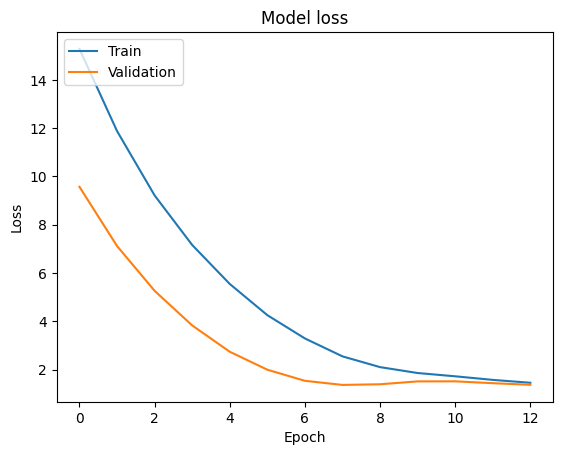

In [8]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
